# Testing New Improvements for Reverse Game of Life

This notebook tests the four new experimental modules:
1. **Feature Engineering** — radius-based neighbour features
2. **Generation Depth Experiment** — F1/accuracy vs. history depth
3. **Full-Board Architectures** — CNN / MLP / U-Net predicting the entire board
4. **Forward Consistency Evaluation** — GoL forward-step validation metric

## 0. Imports & Configuration

In [46]:
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split

from functions import (
    load_reverse_df,
    prepare_reverse_dataset,
    to_numpy_4d,
    build_and_train_cnn,
    evaluate_model,
)

from feature_engineering import add_radius_features
from generation_depth_experiment import evaluate_depth_impact
from full_board_architectures import (
    build_full_cnn_model,
    build_full_mlp_model,
    build_unet_model,
)
from forward_consistency_eval import evaluate_forward_consistency, game_of_life_step

print(f"TensorFlow {tf.__version__}")
print(f"GPUs available: {tf.config.list_physical_devices('GPU')}")

TensorFlow 2.19.0
GPUs available: []


In [47]:
# ---- Knobs (adjust to your data) ----
SIZE = 10
AMOUNT_BOARDS = 10000
GEN = 3           # generation depth for single-run experiments
EPOCHS = 10
BATCH_SIZE = 32

## Helper: load full-board data

The existing `prepare_reverse_dataset` extracts a *single pixel* as the target.  
For full-board architectures we need the **entire last board** as the target.

In [48]:
def load_full_board_data(size, amount_boards, gen, test_size=0.1, random_state=365):
    """Load reverse data and split into (X, y) where y is the full target board.

    Returns
    -------
    X_train, X_test : np.ndarray  shape (N, size, size, gen-1)
    y_train, y_test : np.ndarray  shape (N, size, size, 1)
    """
    reverse_df = load_reverse_df(size, amount_boards, gen)

    n_features = (gen - 1) * size * size
    n_target   = size * size

    X_all = reverse_df.iloc[:, :n_features].to_numpy().reshape(-1, size, size, gen - 1).astype('float32')
    y_all = reverse_df.iloc[:, n_features:n_features + n_target].to_numpy().reshape(-1, size, size, 1).astype('float32')

    X_train, X_test, y_train, y_test = train_test_split(
        X_all, y_all, test_size=test_size, random_state=random_state
    )
    return X_train, X_test, y_train, y_test


# Quick sanity check
X_train, X_test, y_train, y_test = load_full_board_data(SIZE, AMOUNT_BOARDS, GEN)
print(f"X_train: {X_train.shape}  y_train: {y_train.shape}")
print(f"X_test:  {X_test.shape}   y_test:  {y_test.shape}")

X_train: (358731, 10, 10, 2)  y_train: (358731, 10, 10, 1)
X_test:  (39860, 10, 10, 2)   y_test:  (39860, 10, 10, 1)


---
## 1. Feature Engineering — Radius Neighbour Counts

In [49]:
# Add radius-1, radius-2, radius-3 neighbour-count channels
X_train_aug = add_radius_features(X_train).numpy()
X_test_aug  = add_radius_features(X_test).numpy()

print(f"Original channels : {X_train.shape[-1]}")
print(f"Augmented channels: {X_train_aug.shape[-1]}  (added 3 radius features)")

Original channels : 2
Augmented channels: 5  (added 3 radius features)


In [50]:
# Train a full-board CNN on the augmented features
model_aug = build_full_cnn_model(input_shape=X_train_aug.shape[1:])
model_aug.summary()

Model: "FullCNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_36 (InputLayer)     │ (None, 10, 10, 5)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_171 (Conv2D)             │ (None, 10, 10, 64)     │         2,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_172 (Conv2D)             │ (None, 10, 10, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_173 (Conv2D)             │ (None, 10, 10, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_174 (Conv2D)             │ (None, 10, 10, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_175 (Conv2D)             │ (None, 10, 10, 1)      │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 298,241 (1.14 MB)

 Trainable params: 298,241 (1.14 MB)

 Non-trainable params: 0 (0.00 B)

In [51]:
history_aug = model_aug.fit(
    X_train_aug, y_train,
    validation_split=0.1,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
)

y_pred_aug = model_aug.predict(X_test_aug)
aug_acc = np.mean((y_pred_aug > 0.5).astype(int) == y_test.astype(int))
print(f"\nAugmented-feature CNN — pixel accuracy: {aug_acc:.4f}")

Epoch 1/10
10090/10090 ━━━━━━━━━━━━━━━━━━━━ 446s 44ms/step - accuracy: 0.8049 - loss: 0.4119 - val_accuracy: 0.8239 - val_loss: 0.3729
Epoch 2/10
10090/10090 ━━━━━━━━━━━━━━━━━━━━ 449s 45ms/step - accuracy: 0.8274 - loss: 0.3664 - val_accuracy: 0.8317 - val_loss: 0.3606
Epoch 3/10
10090/10090 ━━━━━━━━━━━━━━━━━━━━ 487s 48ms/step - accuracy: 0.8335 - loss: 0.3571 - val_accuracy: 0.8349 - val_loss: 0.3558
Epoch 4/10
10090/10090 ━━━━━━━━━━━━━━━━━━━━ 456s 45ms/step - accuracy: 0.8374 - loss: 0.3511 - val_accuracy: 0.8374 - val_loss: 0.3515
Epoch 5/10
10090/10090 ━━━━━━━━━━━━━━━━━━━━ 454s 45ms/step - accuracy: 0.8394 - loss: 0.3484 - val_accuracy: 0.8388 - val_loss: 0.3491
Epoch 6/10
10090/10090 ━━━━━━━━━━━━━━━━━━━━ 442s 44ms/step - accuracy: 0.8410 - loss: 0.3457 - val_accuracy: 0.8401 - val_loss: 0.3473
Epoch 7/10
10090/10090 ━━━━━━━━━━━━━━━━━━━━ 502s 44ms/step - accuracy: 0.8419 - loss: 0.3441 - val_accuracy: 0.8404 - val_loss: 0.3469
Epoch 8/10
10090/10090 ━━━━━━━━━━━━━━━━━━━━ 444s 44ms/s

In [ ]:
# Compare: same architecture WITHOUT radius features
model_base = build_full_cnn_model(input_shape=X_train.shape[1:])

model_base.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=0,


y_pred_base = model_base.predict(X_test)
base_acc = np.mean((y_pred_base > 0.5).astype(int) == y_test.astype(int))
print(f"Baseline CNN — pixel accuracy:           {base_acc:.4f}")
print(f"Augmented CNN — pixel accuracy:           {aug_acc:.4f}")
print(f"Improvement:                              {aug_acc - base_acc:+.4f}")

1246/1246 ━━━━━━━━━━━━━━━━━━━━ 22s 18ms/step
Baseline CNN — pixel accuracy:           0.8212
Augmented CNN — pixel accuracy:           0.8412
Improvement:                              +0.0200


---
## 2. Generation Depth Experiment


  Generation depth: 2
  Accuracy: 0.8694  |  F1: 0.6434

  Generation depth: 3
  Accuracy: 0.8220  |  F1: 0.4614

  Generation depth: 4
  Accuracy: 0.8102  |  F1: 0.3467


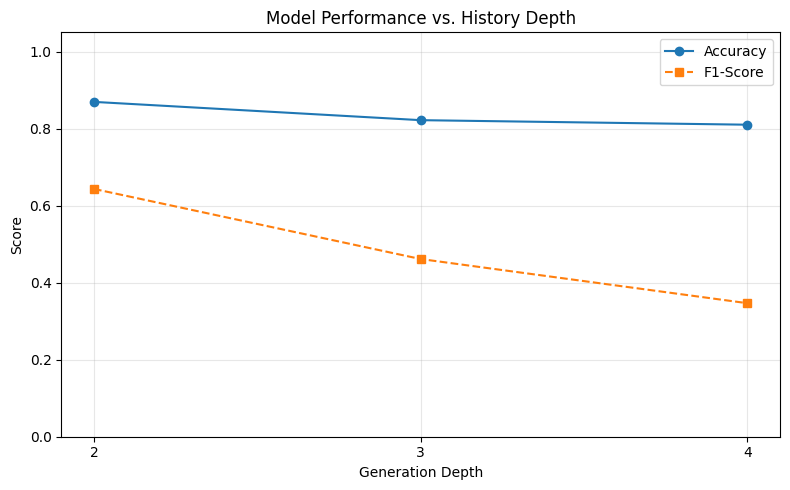

{2: {'accuracy': 0.8694131884415905, 'f1': 0.6433854326146807},
 3: {'accuracy': 0.8219545910687406, 'f1': 0.461394264446841},
 4: {'accuracy': 0.8101526834891764, 'f1': 0.34671488126039673}}

In [53]:
def data_loader_for_depth(gen):
    """Return (X_train, y_train, X_test, y_test) for the given generation depth.
    
    y keeps shape (N, size, size, 1) to match the full-board model output.
    evaluate_depth_impact flattens both predictions and labels for metrics.
    """
    X_tr, X_te, y_tr, y_te = load_full_board_data(SIZE, AMOUNT_BOARDS, gen)
    return X_tr, y_tr, X_te, y_te


def cnn_builder(input_shape):
    """Model factory for the depth experiment."""
    return build_full_cnn_model(input_shape)


# NOTE: This requires data files for gen=2..MAX_DEPTH to exist.
# Adjust MAX_DEPTH to match the generation pickle files you have.
MAX_DEPTH = 4

depth_results = evaluate_depth_impact(
    model_builder_fn=cnn_builder,
    data_loader_fn=data_loader_for_depth,
    max_generations=MAX_DEPTH,
    min_generations=2,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
)

depth_results

---
## 3. Full-Board Architectures — CNN / MLP / U-Net

In [54]:
# Reload data for a single generation depth
X_train, X_test, y_train, y_test = load_full_board_data(SIZE, AMOUNT_BOARDS, GEN)
input_shape = X_train.shape[1:]
print(f"Input shape: {input_shape}  |  Target shape: {y_train.shape[1:]}")

Input shape: (10, 10, 2)  |  Target shape: (10, 10, 1)


In [55]:
builders = {
    'FullCNN': build_full_cnn_model,
    'FullMLP': build_full_mlp_model,
    'UNet':    build_unet_model,
}

arch_results = {}

for name, builder in builders.items():
    print(f"\n{'='*50}")
    print(f"  Training: {name}")
    print(f"{'='*50}")

    model = builder(input_shape)
    model.fit(
        X_train, y_train,
        validation_split=0.1,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        verbose=1,
    )

    y_pred = model.predict(X_test)
    pixel_acc = np.mean((y_pred > 0.5).astype(int) == y_test.astype(int))
    board_acc = np.mean(
        np.all((y_pred > 0.5).astype(int) == y_test.astype(int), axis=(1, 2, 3))
    )

    arch_results[name] = {'pixel_acc': pixel_acc, 'board_acc': board_acc}
    print(f"  Pixel accuracy: {pixel_acc:.4f}  |  Board accuracy: {board_acc:.4f}")


  Training: FullCNN
Epoch 1/10
10090/10090 ━━━━━━━━━━━━━━━━━━━━ 438s 43ms/step - accuracy: 0.7991 - loss: 0.4264 - val_accuracy: 0.8113 - val_loss: 0.3927
Epoch 2/10
10090/10090 ━━━━━━━━━━━━━━━━━━━━ 456s 45ms/step - accuracy: 0.8140 - loss: 0.3890 - val_accuracy: 0.8166 - val_loss: 0.3853
Epoch 3/10
10090/10090 ━━━━━━━━━━━━━━━━━━━━ 461s 46ms/step - accuracy: 0.8184 - loss: 0.3822 - val_accuracy: 0.8187 - val_loss: 0.3822
Epoch 4/10
10090/10090 ━━━━━━━━━━━━━━━━━━━━ 450s 45ms/step - accuracy: 0.8204 - loss: 0.3793 - val_accuracy: 0.8197 - val_loss: 0.3808
Epoch 5/10
10090/10090 ━━━━━━━━━━━━━━━━━━━━ 450s 45ms/step - accuracy: 0.8217 - loss: 0.3773 - val_accuracy: 0.8202 - val_loss: 0.3800
Epoch 6/10
10090/10090 ━━━━━━━━━━━━━━━━━━━━ 445s 44ms/step - accuracy: 0.8225 - loss: 0.3759 - val_accuracy: 0.8211 - val_loss: 0.3787
Epoch 7/10
10090/10090 ━━━━━━━━━━━━━━━━━━━━ 458s 45ms/step - accuracy: 0.8231 - loss: 0.3750 - val_accuracy: 0.8211 - val_loss: 0.3784
Epoch 8/10
10090/10090 ━━━━━━━━━━━

In [56]:
import pandas as pd

df_results = pd.DataFrame(arch_results).T
df_results.index.name = 'Architecture'
df_results.round(4)

,pixel_acc,board_acc
Architecture,,
FullCNN,0.8219,0.0001
FullMLP,0.8467,0.0011
UNet,0.8679,0.0079


---
## 4. Forward Consistency Evaluation

Predict T-1, step it forward via GoL rules, and check if it matches the original T board.

In [57]:
# Use the best full-board model from Section 3 (or retrain one)
best_name = max(arch_results, key=lambda k: arch_results[k]['pixel_acc'])
print(f"Using best architecture from Section 3: {best_name}")

best_model = builders[best_name](input_shape)
best_model.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=0,
)

Using best architecture from Section 3: UNet


In [58]:
# X_test is the board at time T.  The model predicts T-1.
consistency = evaluate_forward_consistency(best_model, X_test, threshold=0.5)

print(f"\nPixel-level consistency : {consistency['pixel_accuracy']:.4f}")
print(f"Board-level consistency : {consistency['board_accuracy']:.4f}")

Forward-consistency  |  Pixel acc: 0.7181  |  Board acc: 0.0004

Pixel-level consistency : 0.7181
Board-level consistency : 0.0004


Forward-consistency  |  Pixel acc: 0.7420  |  Board acc: 0.0012
Forward-consistency  |  Pixel acc: 0.7172  |  Board acc: 0.0011
Forward-consistency  |  Pixel acc: 0.7198  |  Board acc: 0.0005


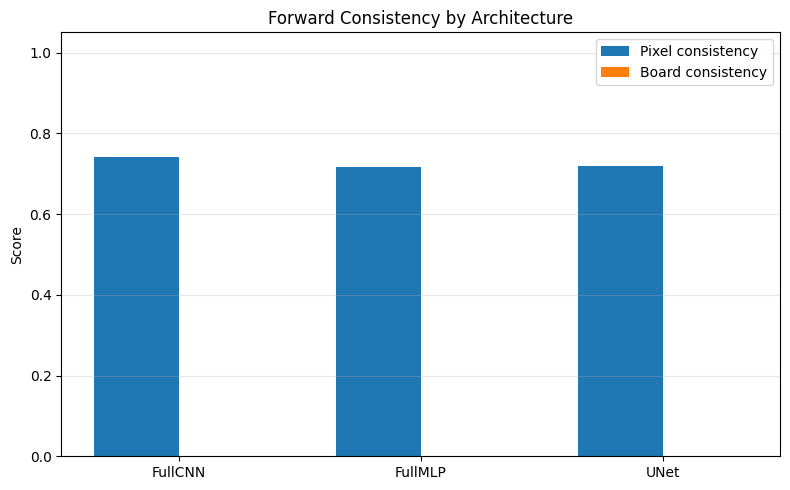

In [59]:
# Run forward-consistency on ALL three architectures for comparison
import matplotlib.pyplot as plt

fc_results = {}
for name, builder in builders.items():
    m = builder(input_shape)
    m.fit(X_train, y_train, validation_split=0.1,
          epochs=EPOCHS, batch_size=BATCH_SIZE, verbose=0)
    fc = evaluate_forward_consistency(m, X_test)
    fc_results[name] = fc

# Plot
names  = list(fc_results.keys())
px_acc = [fc_results[n]['pixel_accuracy'] for n in names]
bd_acc = [fc_results[n]['board_accuracy'] for n in names]

x = np.arange(len(names))
w = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - w/2, px_acc, w, label='Pixel consistency')
ax.bar(x + w/2, bd_acc, w, label='Board consistency')
ax.set_xticks(x)
ax.set_xticklabels(names)
ax.set_ylabel('Score')
ax.set_title('Forward Consistency by Architecture')
ax.set_ylim(0, 1.05)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

---
## 5. Quick Sanity Check — GoL Forward Step

Verify that `game_of_life_step` matches `make_move` from `functions.py`.

In [60]:
from functions import make_move

# Use a random board from the test set
sample = X_test[0, :, :, 0].astype(int)

# Our vectorised numpy step (no wrapping)
next_np = game_of_life_step(sample[np.newaxis])[0]

# Original make_move (wrapping edges)
next_original = np.array(make_move(sample.tolist(), moves=1))

# Note: game_of_life_step uses zero-padding (dead borders),
# while make_move wraps edges. Interior cells should still agree.
interior_match = np.all(next_np[1:-1, 1:-1] == next_original[1:-1, 1:-1])
full_match = np.all(next_np == next_original)

print(f"Interior cells match: {interior_match}")
print(f"Full board match:     {full_match}")
if not full_match:
    diff = np.sum(next_np != next_original)
    print(f"Edge cells differ:    {diff} (expected due to different boundary conditions)")

Interior cells match: True
Full board match:     True
